# Notebook 3 — MobileNetV2 Transfer Learning

**Project:** Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning

This notebook builds a MobileNetV2 transfer-learning model using the same train, validation, and test splits created in Notebook 1.

### Objectives
- Load the standardized dataset splits.
- Apply image preprocessing and augmentation.
- Use MobileNetV2 pretrained on ImageNet as the feature extractor.
- Train a four-class classifier: Closed, Open, no_yawn, yawn.
- Evaluate accuracy, precision, recall, F1-score, and confusion matrix.
- Generate sample predictions and misclassified examples.
- Save the trained model and evaluation metrics for Notebook 4.


In [1]:
# Cell 1 — Imports

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("MobileNetV2 notebook initialized successfully.")


TensorFlow version: 2.21.0
MobileNetV2 notebook initialized successfully.


In [2]:
# Cell 2 — Configuration

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 15

CLASS_NAMES = ["Closed", "Open", "no_yawn", "yawn"]

# Notebook is inside the notebooks folder, so project-level folders use ../
OUTPUTS_DIR = "../outputs"
MODELS_DIR = "../models"

TRAIN_CSV = os.path.join(OUTPUTS_DIR, "train_split.csv")
VAL_CSV = os.path.join(OUTPUTS_DIR, "validation_split.csv")
TEST_CSV = os.path.join(OUTPUTS_DIR, "test_split.csv")

MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2.keras")
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2_final.keras")
METRICS_PATH = os.path.join(OUTPUTS_DIR, "mobilenetv2_metrics.csv")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration ready.")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)


Configuration ready.
Image size: (224, 224)
Batch size: 32
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


In [3]:
# Cell 3 — Load Dataset Splits

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["label"].value_counts().sort_index())


Training samples: 2030
Validation samples: 435
Test samples: 435

Training distribution:
label
0    508
1    508
2    508
3    506
Name: count, dtype: int64

Validation distribution:
label
0    109
1    109
2    109
3    108
Name: count, dtype: int64

Test distribution:
label
0    109
1    109
2    108
3    109
Name: count, dtype: int64


In [4]:
# Cell 4 — Verify Image Paths

missing_train = train_df.loc[~train_df["filepath"].apply(os.path.exists)]
missing_val = val_df.loc[~val_df["filepath"].apply(os.path.exists)]
missing_test = test_df.loc[~test_df["filepath"].apply(os.path.exists)]

print("Missing training images:", len(missing_train))
print("Missing validation images:", len(missing_val))
print("Missing test images:", len(missing_test))

if len(missing_train) == 0 and len(missing_val) == 0 and len(missing_test) == 0:
    print("All image paths are valid.")
else:
    print("Warning: Some image paths are missing.")


Missing training images: 0
Missing validation images: 0
Missing test images: 0
All image paths are valid.


In [5]:
# Cell 5 — TensorFlow Dataset Pipeline

AUTOTUNE = tf.data.AUTOTUNE

def load_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

print("TensorFlow datasets created.")


TensorFlow datasets created.


## Data Augmentation

Augmentation is applied only during training. Validation and test images are not randomly augmented.

The dataset pipeline normalizes images to **0–1**. A Rescaling layer inside the model converts them to the **-1 to +1 range expected by MobileNetV2**, avoiding double preprocessing.


In [6]:
# Cell 6 — Data Augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomBrightness(0.10),
    ],
    name="data_augmentation"
)

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


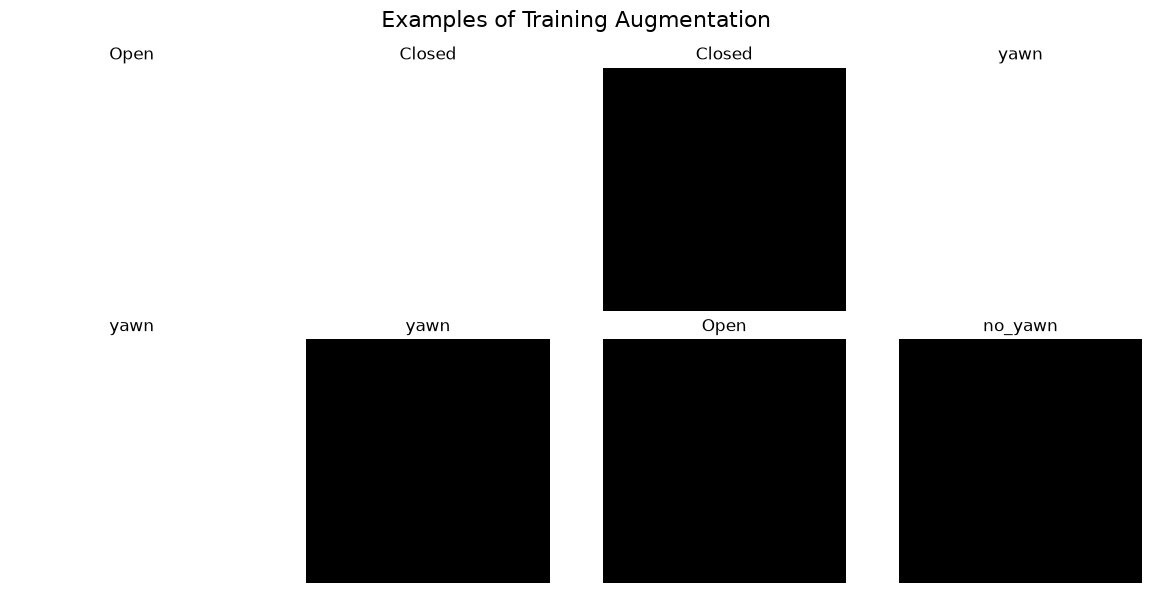

In [7]:
# Cell 7 — Visualize Augmentation

sample_images, sample_labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    augmented_image = data_augmentation(sample_images[i:i+1], training=True)[0]

    ax.imshow(tf.clip_by_value(augmented_image, 0, 1))
    ax.set_title(CLASS_NAMES[int(sample_labels[i])])
    ax.axis("off")

plt.suptitle("Examples of Training Augmentation", fontsize=16)
plt.tight_layout()
plt.show()


## Build MobileNetV2 Model

The pretrained MobileNetV2 convolutional base is frozen during initial training.

**Input → Augmentation → Rescaling to [-1, 1] → MobileNetV2 → Global Average Pooling → Dropout → Dense → Dropout → 4-Class Softmax**


In [8]:
# Cell 8 — Load Pretrained MobileNetV2 Base

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 base loaded.")
print("Trainable:", base_model.trainable)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base loaded.
Trainable: False


In [9]:
# Cell 9 — Build Transfer Learning Model

inputs = keras.Input(shape=(224, 224, 3), name="input_image")

x = data_augmentation(inputs)

# Dataset images are already in [0, 1].
# MobileNetV2 expects approximately [-1, 1].
x = layers.Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenetv2_rescaling"
)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.30, name="dropout_1")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.20, name="dropout_2")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_Drowsiness")

model.summary()


Model: "MobileNetV2_Drowsiness"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_rescaling           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Cell 10 — Compile Model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


In [11]:
# Cell 11 — Callbacks

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback
]

print("Callbacks configured.")


Callbacks configured.


In [12]:
# Cell 12 — Train MobileNetV2

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_time_minutes = (time.time() - start_time) / 60

print(f"Training completed in {training_time_minutes:.2f} minutes.")


Epoch 1/15


d:\driver-drowsiness-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.3803 - loss: 1.2608
Epoch 1: val_accuracy improved from None to 0.64138, saving model to ../models\mobilenetv2.keras

Epoch 1: finished saving model to ../models\mobilenetv2.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 896ms/step - accuracy: 0.3803 - loss: 1.2608 - val_accuracy: 0.6414 - val_loss: 1.0174 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.3990 - loss: 1.0986
Epoch 2: val_accuracy improved from 0.64138 to 0.71954, saving model to ../models\mobilenetv2.keras

Epoch 2: finished saving model to ../models\mobilenetv2.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3990 - loss: 1.0986 - val_accuracy: 0.7195 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.4325 - loss: 1.0507
Epoch 3: val_accuracy did not improve from 0.71954
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.4325 - loss: 1.0507 - val_accuracy: 0.6989 - 

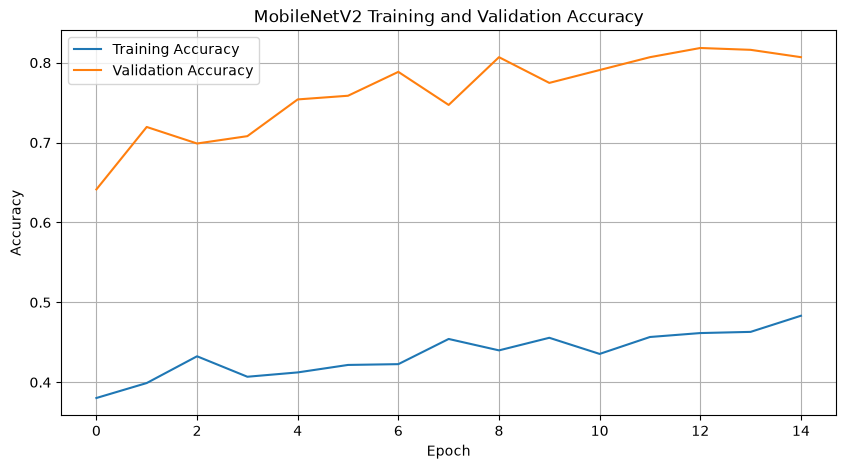

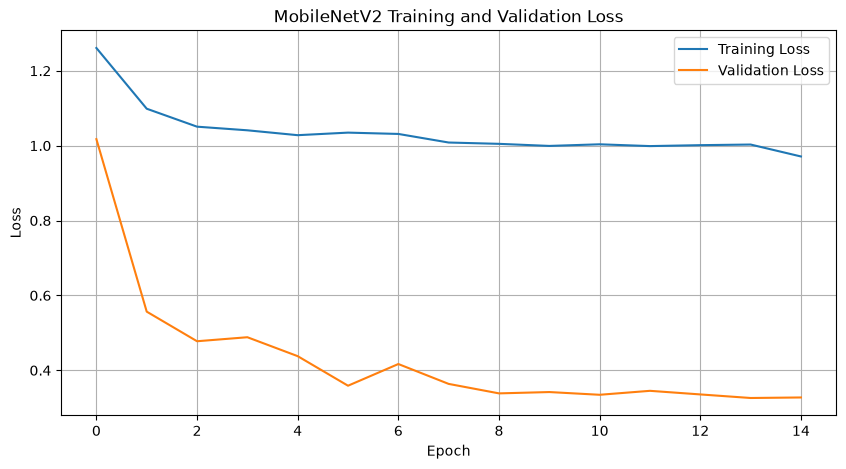

In [13]:
# Cell 13 — Training History

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# Cell 14 — Load Best Saved Model

best_model = keras.models.load_model(MODEL_PATH)

print("Best MobileNetV2 model loaded from:")
print(os.path.abspath(MODEL_PATH))


Best MobileNetV2 model loaded from:
d:\driver-drowsiness-detection\models\mobilenetv2.keras


In [15]:
# Cell 15 — Test Evaluation

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 582ms/step - accuracy: 0.8414 - loss: 0.3229
Test Loss: 0.3229
Test Accuracy: 0.8414


In [16]:
# Cell 16 — Predictions

test_probabilities = best_model.predict(test_ds, verbose=1)
test_predictions = np.argmax(test_probabilities, axis=1)

test_true_labels = test_df["label"].to_numpy()

print("Number of predictions:", len(test_predictions))
print("Number of true labels:", len(test_true_labels))


14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 658ms/step
Number of predictions: 435
Number of true labels: 435


In [17]:
# Cell 17 — Prediction Distribution

unique, counts = np.unique(test_predictions, return_counts=True)

print("Prediction distribution:")

for idx, count in zip(unique, counts):
    print(f"{idx} -> {CLASS_NAMES[idx]}: {count}")

print("\nExpected test distribution:")
for idx in range(NUM_CLASSES):
    print(f"{idx} -> {CLASS_NAMES[idx]}: {(test_true_labels == idx).sum()}")


Prediction distribution:
0 -> Closed: 108
1 -> Open: 110
2 -> no_yawn: 174
3 -> yawn: 43

Expected test distribution:
0 -> Closed: 109
1 -> Open: 109
2 -> no_yawn: 108
3 -> yawn: 109


In [18]:
# Cell 18 — Classification Report

report = classification_report(
    test_true_labels,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)


              precision    recall  f1-score   support

      Closed       0.99      0.98      0.99       109
        Open       0.98      0.99      0.99       109
     no_yawn       0.62      1.00      0.77       108
        yawn       1.00      0.39      0.57       109

    accuracy                           0.84       435
   macro avg       0.90      0.84      0.83       435
weighted avg       0.90      0.84      0.83       435



In [19]:
# Cell 19 — Overall Metrics

accuracy = accuracy_score(test_true_labels, test_predictions)
precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Training Time (minutes): {training_time_minutes:.2f}")


Accuracy : 0.8414
Precision: 0.8990
Recall   : 0.8414
F1 Score : 0.8262
Training Time (minutes): 17.03


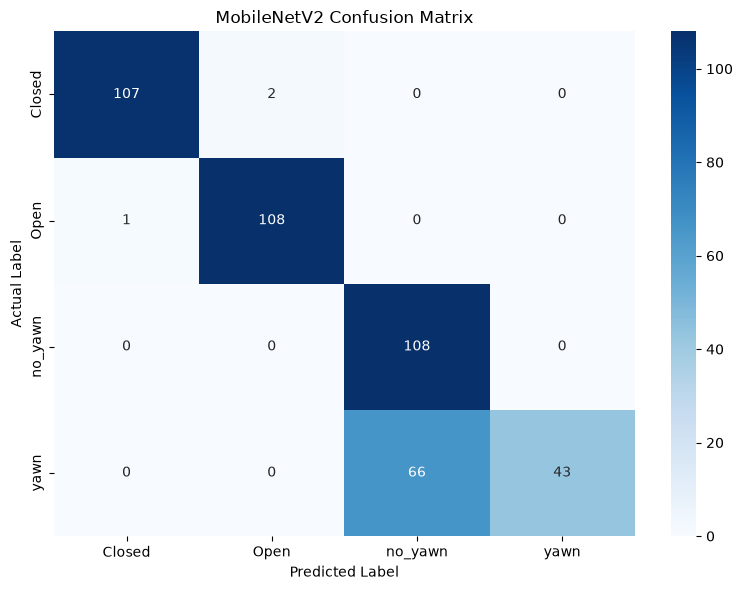

In [20]:
# Cell 20 — Confusion Matrix

cm = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.show()


In [21]:
# Cell 21 — Per-Class Performance

report_dict = classification_report(
    test_true_labels,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

per_class_df = pd.DataFrame(report_dict).T

display(
    per_class_df.loc[
        CLASS_NAMES,
        ["precision", "recall", "f1-score", "support"]
    ]
)


,precision,recall,f1-score,support
Closed,0.990741,0.981651,0.986175,109.0
Open,0.981818,0.990826,0.986301,109.0
no_yawn,0.620690,1.000000,0.765957,108.0
yawn,1.000000,0.394495,0.565789,109.0


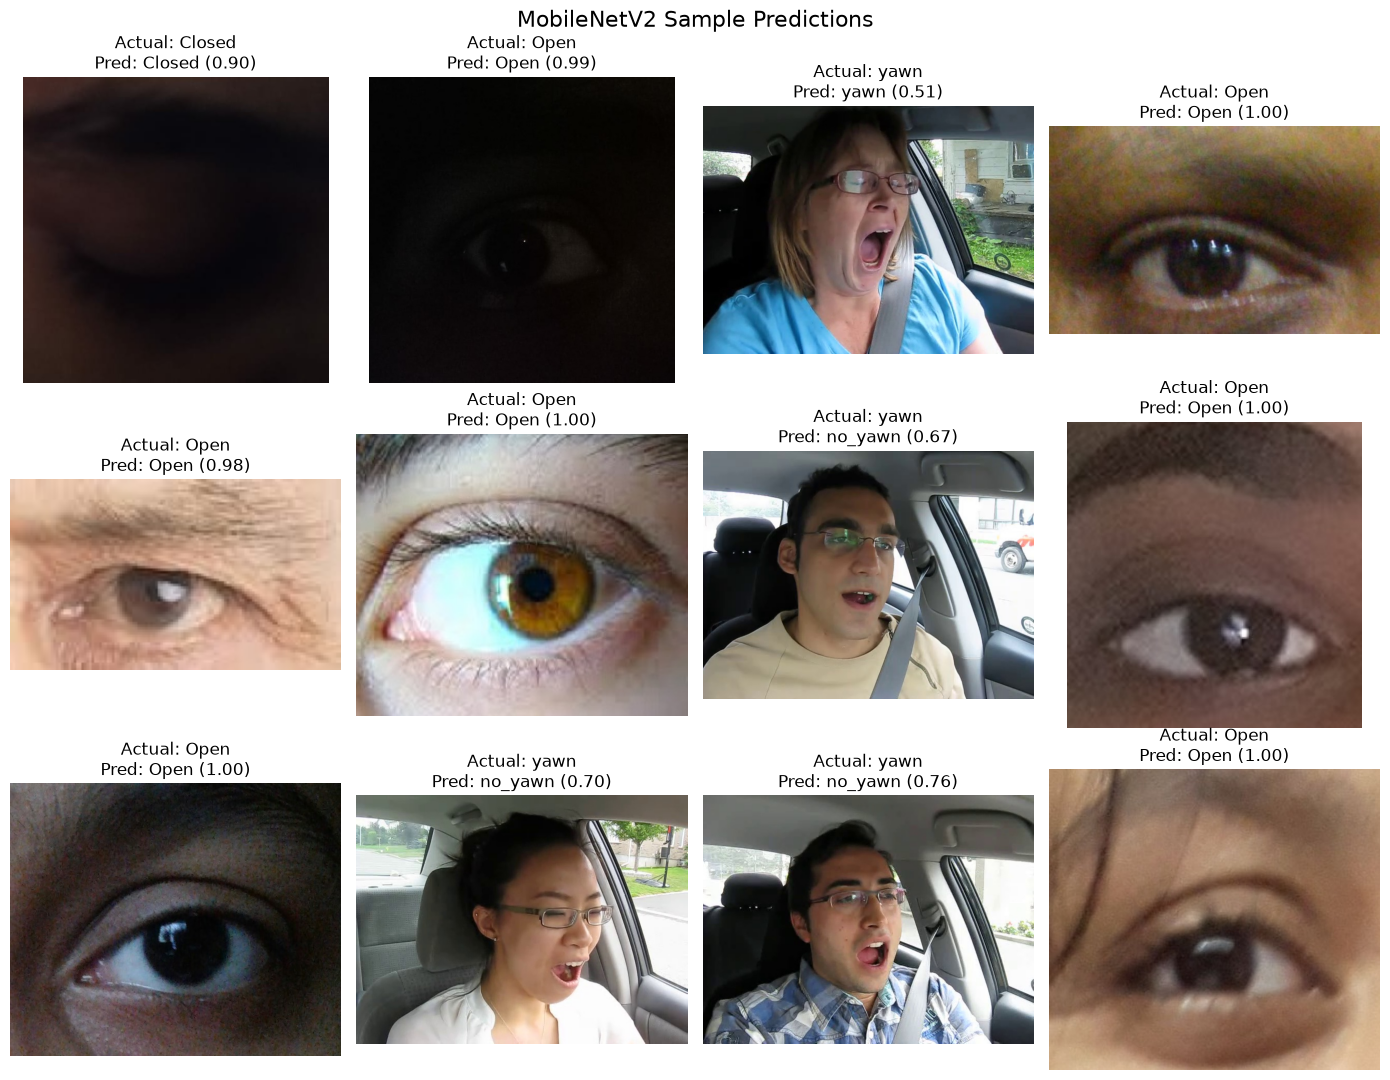

In [22]:
# Cell 22 — Sample Predictions

sample_count = min(12, len(test_df))
sample_indices = np.random.default_rng(SEED).choice(
    len(test_df),
    size=sample_count,
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
axes = axes.flatten()

for plot_idx, data_idx in enumerate(sample_indices):
    file_path = test_df.iloc[data_idx]["filepath"]
    true_label = int(test_true_labels[data_idx])
    predicted_label = int(test_predictions[data_idx])
    confidence = float(test_probabilities[data_idx][predicted_label])

    image = Image.open(file_path).convert("RGB")

    axes[plot_idx].imshow(image)
    axes[plot_idx].set_title(
        f"Actual: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[predicted_label]} ({confidence:.2f})"
    )
    axes[plot_idx].axis("off")

for ax in axes[sample_count:]:
    ax.axis("off")

plt.suptitle("MobileNetV2 Sample Predictions", fontsize=16)
plt.tight_layout()
plt.show()


Total misclassified images: 69


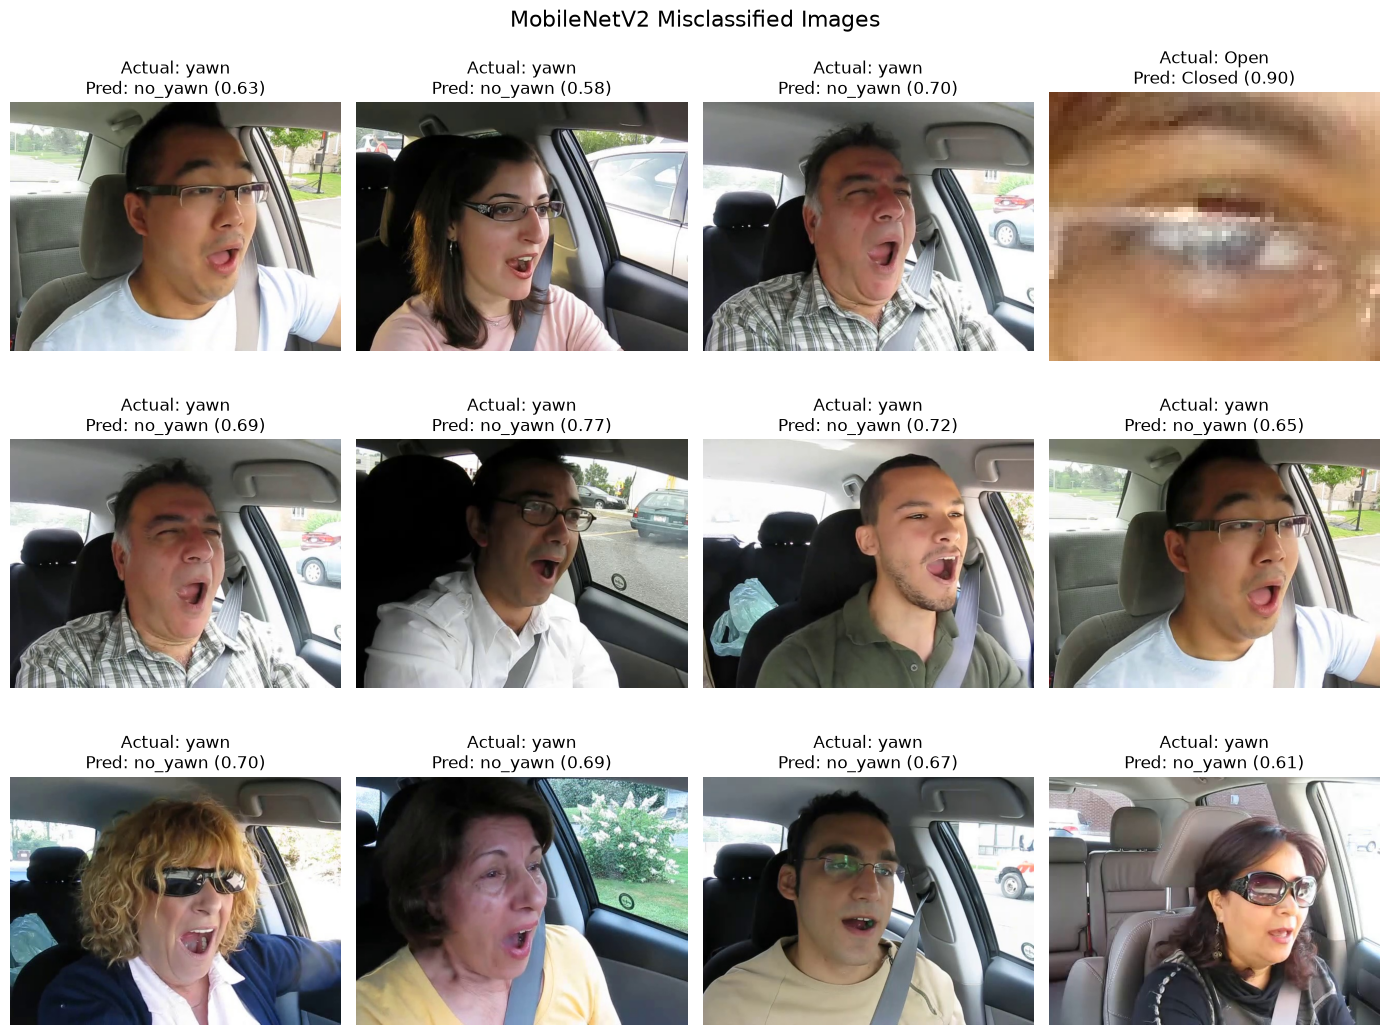

In [23]:
# Cell 23 — Misclassified Images

misclassified_indices = np.where(test_predictions != test_true_labels)[0]

print("Total misclassified images:", len(misclassified_indices))

show_count = min(12, len(misclassified_indices))

if show_count > 0:
    selected = misclassified_indices[:show_count]

    fig, axes = plt.subplots(3, 4, figsize=(14, 11))
    axes = axes.flatten()

    for plot_idx, data_idx in enumerate(selected):
        file_path = test_df.iloc[data_idx]["filepath"]
        true_label = int(test_true_labels[data_idx])
        predicted_label = int(test_predictions[data_idx])
        confidence = float(test_probabilities[data_idx][predicted_label])

        image = Image.open(file_path).convert("RGB")

        axes[plot_idx].imshow(image)
        axes[plot_idx].set_title(
            f"Actual: {CLASS_NAMES[true_label]}\n"
            f"Pred: {CLASS_NAMES[predicted_label]} ({confidence:.2f})"
        )
        axes[plot_idx].axis("off")

    for ax in axes[show_count:]:
        ax.axis("off")

    plt.suptitle("MobileNetV2 Misclassified Images", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images found.")


In [24]:
# Cell 24 — Save Final Model

best_model.save(FINAL_MODEL_PATH)

print("Final MobileNetV2 model saved:")
print(os.path.abspath(FINAL_MODEL_PATH))


Final MobileNetV2 model saved:
d:\driver-drowsiness-detection\models\mobilenetv2_final.keras


In [25]:
# Cell 25 — Save Metrics

mobilenet_metrics = pd.DataFrame(
    [
        {
            "Model": "MobileNetV2",
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Training Time (minutes)": training_time_minutes
        }
    ]
)

mobilenet_metrics.to_csv(METRICS_PATH, index=False)

print("Metrics saved:")
print(os.path.abspath(METRICS_PATH))

display(mobilenet_metrics)


Metrics saved:
d:\driver-drowsiness-detection\outputs\mobilenetv2_metrics.csv


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (minutes)
0,MobileNetV2,0.841379,0.89895,0.841379,0.826194,17.029226


## Notebook 3 Summary

The MobileNetV2 transfer-learning model has been trained and evaluated using the same dataset split as the Custom CNN baseline.

### Saved outputs

- `../models/mobilenetv2.keras` — best checkpoint
- `../models/mobilenetv2_final.keras` — final evaluated model
- `../outputs/mobilenetv2_metrics.csv` — evaluation metrics

These outputs will be used in **Notebook 4 — Model Comparison**.
